# Graphics

In [1]:
import sys
from pathlib import Path

# Jupyter has no __file__ to anchor a relative import on, and the notebook's
# kernel env may not have the package installed -> add the repo root by hand.
REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import nd_phase_unwrap.io as io
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn # For visualization of pandas df
import dabest

Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:01<00:00,  9.73it/s]

Numba compilation complete!


## 4D Phantom

### Heatmap

In [2]:
data_path = REPO_ROOT / 'test_data'
in_path = data_path / '3+1D_phantom'
out_paths = {
    'IGC': data_path / 'IGC_unwrapped',
    'Laplace': data_path / 'Laplace_unwrapped',
    'ROMEO': data_path / 'ROMEO_unwrapped',
}
# 0 wraps == ground truth (div_factor = 1 + 2*0 leaves the phase untouched)
truth_path = in_path / "0wraps.npy"

truth_array = np.angle(io.load_numpy_data(truth_path))
mask = (np.abs(truth_array) != 0).astype(bool)

# save results in dataframe
row_indices = list(range(6))
col_indices = list(np.arange(1.0, 3.5, 0.5)) + ["no noise"]

heatmaps = {}
for algorithm, out_path in out_paths.items():
    heatmap_df = pd.DataFrame(np.nan, index=row_indices, columns=col_indices)
    heatmap_df.columns.name = "log(VNR)"
    heatmap_df.index.name = "wraps"

    for file in os.listdir(in_path):
        file = Path(file)
        if not file.name.endswith(".npy"):
            continue
        if "VNR" in file.stem:
            vnr = float(file.stem[-3:].replace("_", "."))
        else:
            vnr = "no noise"
        wrapcount = int(file.stem[0])
        div_factor = 1 + 2*wrapcount

        unwrapped_path = out_path / f'{file.stem}_unwrapped.npy'
        if not unwrapped_path.is_file():
            continue
        out_array = io.load_numpy_data(unwrapped_path)

        diff = np.abs(truth_array * div_factor - out_array) < np.pi
        heatmap_df.at[wrapcount, vnr] = diff[mask].mean()

    heatmaps[algorithm] = heatmap_df


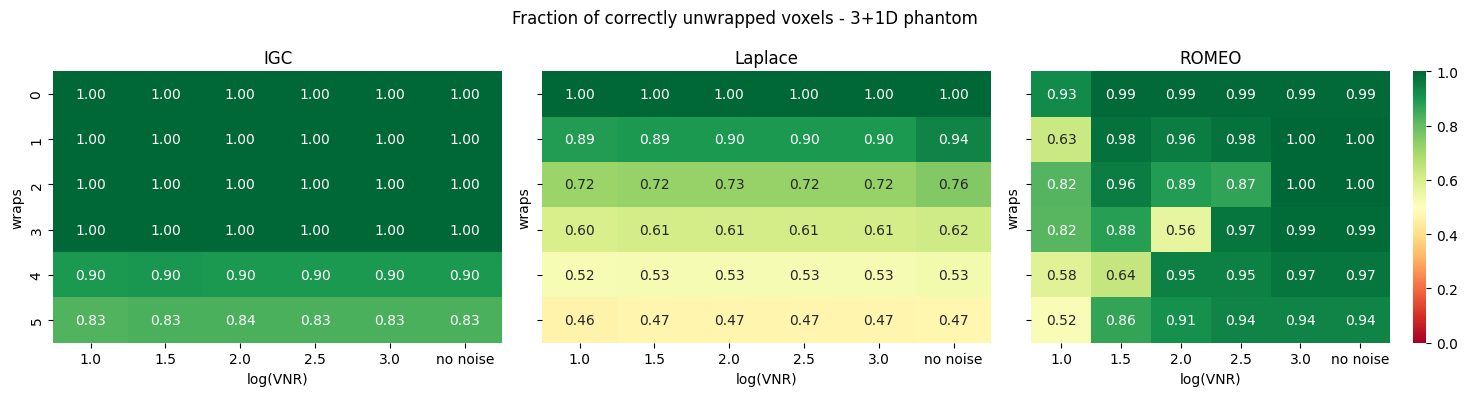

In [3]:
fig, axes = plt.subplots(1, len(heatmaps), figsize=(5 * len(heatmaps), 4), sharey=True)

for axis, (algorithm, heatmap_df) in zip(axes, heatmaps.items()):
    sn.heatmap(heatmap_df, annot=True, fmt='.2f', vmin=0.0,
               cmap='RdYlGn', cbar=axis is axes[-1], ax=axis)
    axis.set_title(algorithm)

fig.suptitle('Fraction of correctly unwrapped voxels - 3+1D phantom')
fig.tight_layout()
# Save fig
# fig.savefig(data_path / '3+1D_phantom_heatmap.png', dpi=150)

## RACLETTE data

`raclette_eval_streaming.csv` holds one row per (subject, VNR, wrap count, algorithm) with the
raw voxel tallies instead of pre-aggregated fractions:

| column | meaning |
| --- | --- |
| `rawdata_name` | subject id (60 subjects) |
| `VNR` | velocity-to-noise ratio, 1.0 ... 5.0, or `no noise` |
| `wraps` | number of induced wraps, 0 ... 5 |
| `algorithm` | `IGC`, `Laplace`, `ROMEO`, or `unprocessed` (the wrapped input = baseline) |
| `total_size` / `mask_size` | voxels in the volume / inside the mask |
| `n_correct` / `n_incorrect` | masked voxels unwrapped (in)correctly; they sum to `mask_size` |

The baseline is only evaluated noise-free, once per (subject, wrap count), so every algorithm
cell is compared against the noise-free wrapped input of the same subject and wrap count.

In [4]:
raclette_dir = data_path / 'raclette_eval'
BASELINE = 'unprocessed'

raw = pd.read_csv(raclette_dir / 'raclette_eval_streaming.csv').rename(
    columns={'rawdata_name': 'subject', 'VNR exponent': 'vnr', 'wraps': 'num_wraps'})
raw['correct_fraction'] = raw.n_correct / raw.mask_size

# algorithm rows carry a numeric VNR; the baseline rows are the 'no noise' ones
cases = raw[raw.algorithm != BASELINE].copy()
cases['vnr'] = cases.vnr.astype(float)

algorithms = sorted(cases.algorithm.unique())
vnr_levels = sorted(float(v) for v in cases.vnr.unique())
wraps_levels = sorted(int(w) for w in cases.num_wraps.unique())

# 0 wraps needs no unwrapping (correct_fraction == 1) -> drop it from the baseline
baseline = (raw[(raw.algorithm == BASELINE) & (raw.num_wraps.isin(wraps_levels))]
            .set_index(['subject', 'num_wraps'])['correct_fraction']
            .rename('baseline_fraction'))

cases = cases.join(baseline, on=['subject', 'num_wraps'])
# fraction of the initially wrong voxels that the algorithm fixed (<0 -> it made things worse)
cases['improvement'] = ((cases.correct_fraction - cases.baseline_fraction)
                        / (1 - cases.baseline_fraction))

print(f'{cases.subject.nunique()} subjects, wraps {wraps_levels}, VNR {vnr_levels}')
cases.groupby(['algorithm', 'num_wraps'])[['correct_fraction', 'improvement']].mean().unstack(0)

60 subjects, wraps [0, 1, 2, 3, 4, 5], VNR [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]


correct_fraction                     improvement                    
algorithm              IGC   Laplace     ROMEO         IGC   Laplace     ROMEO
num_wraps                                                                     
0                 0.967578  0.989349  0.861224        -inf      -inf      -inf
1                 0.959110  0.962929  0.827573   -1.473109 -0.423678 -9.341385
2                 0.932307  0.926301  0.804898   -0.206223 -0.035570 -2.907250
3                 0.906166  0.893401  0.781119    0.075223  0.030478 -1.550114
4                 0.878664  0.863615  0.763232    0.127851  0.061210 -0.914003
5                 0.853194  0.835923  0.741479    0.153656  0.079782 -0.615269

### Heatmap - correctly unwrapped fraction

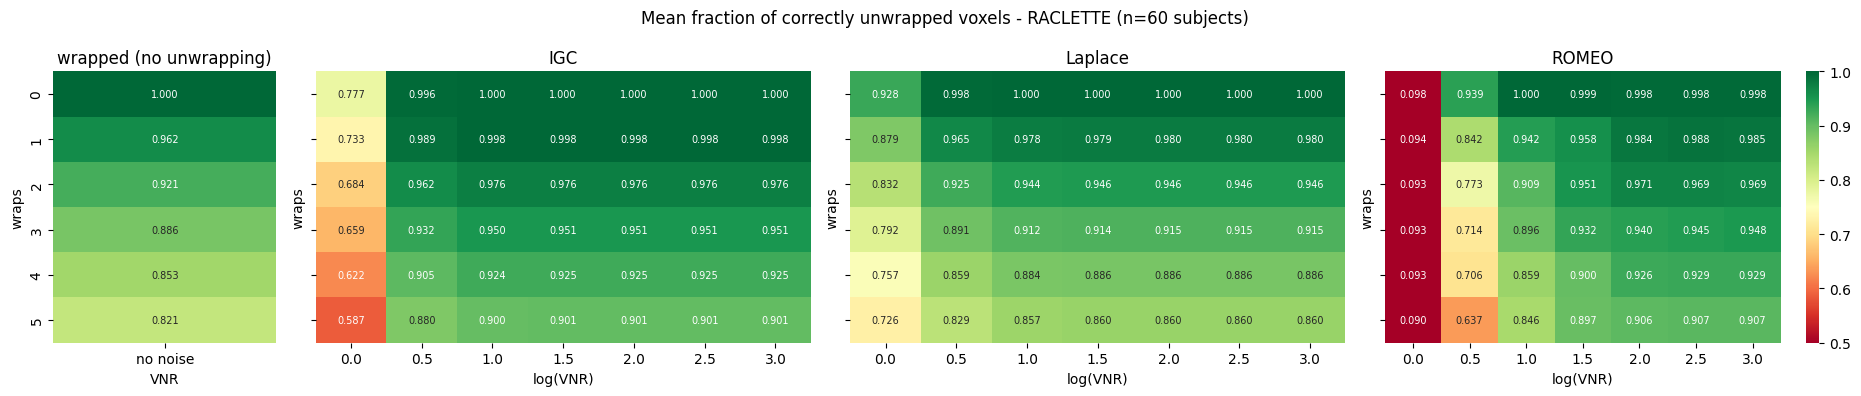

In [5]:
base_pivot = (baseline.reset_index().groupby('num_wraps')['baseline_fraction']
              .mean().to_frame('no noise'))
base_pivot.index.name = 'wraps'

fig, axes = plt.subplots(1, len(algorithms) + 1, figsize=(5.5 * len(algorithms) + 2.5, 4),
                         sharey=True,
                         gridspec_kw={'width_ratios': [0.45] + [1] * len(algorithms)})
annot_kws = {'fontsize': 7}

sn.heatmap(base_pivot, annot=True, fmt='.3f', vmin=0.5, vmax=1.0, cmap='RdYlGn',
           cbar=False, ax=axes[0], annot_kws=annot_kws)
axes[0].set_title('wrapped (no unwrapping)')
axes[0].set_xlabel('VNR')

for axis, algo in zip(axes[1:], algorithms):
    pivot = cases[cases.algorithm == algo].pivot_table(
        index='num_wraps', columns='vnr', values='correct_fraction', aggfunc='mean')
    pivot.index.name, pivot.columns.name = 'wraps', 'log(VNR)'
    sn.heatmap(pivot, annot=True, fmt='.3f', vmin=0.5, vmax=1.0, cmap='RdYlGn',
               cbar=axis is axes[-1], ax=axis, annot_kws=annot_kws)
    axis.set_title(algo)

fig.suptitle(f'Mean fraction of correctly unwrapped voxels - RACLETTE '
             f'(n={cases.subject.nunique()} subjects)')
fig.tight_layout()
# fig.savefig(raclette_dir / 'raclette_correct_fraction_heatmap.png', dpi=150)

### Heatmap - improvement over the wrapped input

Improvement is `(correct - wrapped) / (1 - wrapped)`: 1.0 means every initially wrapped voxel was
recovered, 0.0 means no gain over leaving the data alone, negative means the unwrapping
introduced errors.

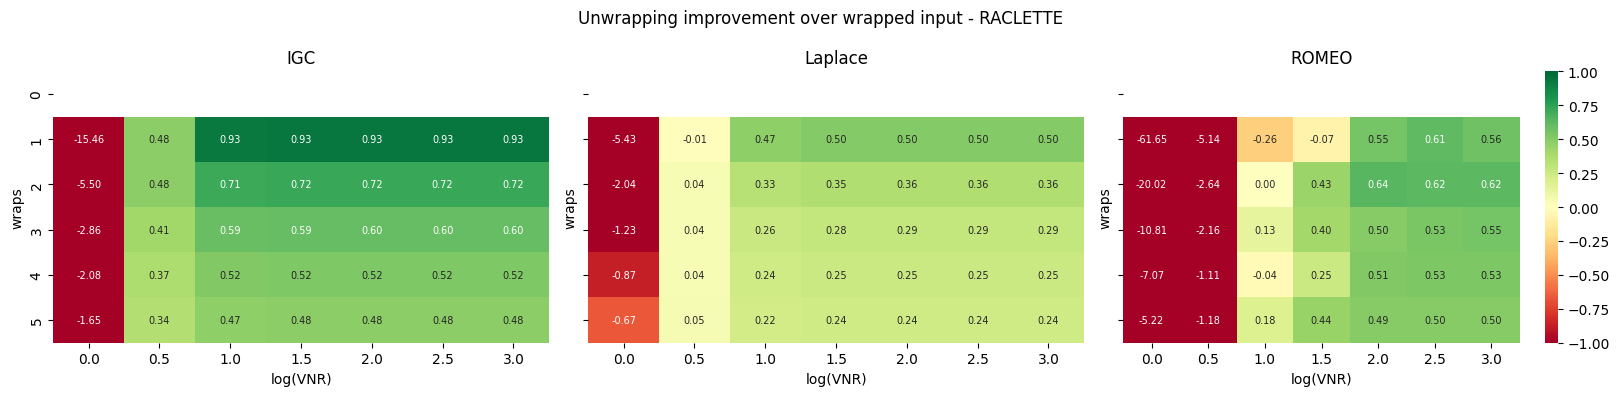

In [6]:
fig, axes = plt.subplots(1, len(algorithms), figsize=(5.5 * len(algorithms), 4), sharey=True)

for axis, algo in zip(axes, algorithms):
    pivot = cases[cases.algorithm == algo].pivot_table(
        index='num_wraps', columns='vnr', values='improvement', aggfunc='mean')
    pivot.index.name, pivot.columns.name = 'wraps', 'log(VNR)'
    sn.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', center=0, vmin=-1, vmax=1,
               cbar=axis is axes[-1], ax=axis, annot_kws={'fontsize': 7})
    axis.set_title(algo)

fig.suptitle('Unwrapping improvement over wrapped input - RACLETTE')
fig.tight_layout()
# fig.savefig(raclette_dir / 'raclette_improvement_heatmap.png', dpi=150)

### Accuracy vs wrap count

The heatmaps above are flat along VNR - the differences between VNR 1.0 and 5.0 sit in the 4th
decimal - so the wrap count is the only factor that moves the result and the VNR axis can be
pooled.

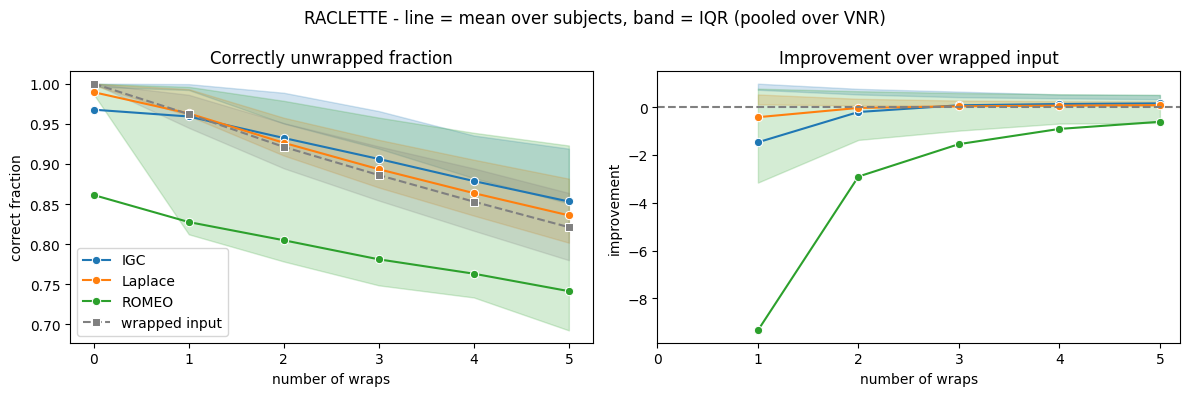

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sn.lineplot(data=cases, x='num_wraps', y='correct_fraction', hue='algorithm',
            marker='o', errorbar=('pi', 50), ax=axes[0])
sn.lineplot(data=baseline.reset_index(), x='num_wraps', y='baseline_fraction', color='grey',
            ls='--', marker='s', errorbar=('pi', 50), ax=axes[0], label='wrapped input')
axes[0].set(xlabel='number of wraps', ylabel='correct fraction', xticks=wraps_levels,
            title='Correctly unwrapped fraction')

sn.lineplot(data=cases, x='num_wraps', y='improvement', hue='algorithm',
            marker='o', errorbar=('pi', 50), ax=axes[1], legend=False)
axes[1].axhline(0, color='grey', ls='--')
axes[1].set(xlabel='number of wraps', ylabel='improvement', xticks=wraps_levels,
            title='Improvement over wrapped input')

fig.suptitle('RACLETTE - line = mean over subjects, band = IQR (pooled over VNR)')
fig.tight_layout()

### Cumming plot (DABEST)

Paired against the wrapped input of the same subject. VNR barely matters here, so the plots use
the least noisy setting; change `CUMMING_VNR` / `CUMMING_WRAPS` to look at other cells.

c:\Users\jar048\.conda\envs\evalgc\Lib\site-packages\dabest\_effsize_objects.py:306: UserWarning: The lower limit of the interval was in the bottom 10 values. The result should be considered unstable.
  warnings.warn(
c:\Users\jar048\.conda\envs\evalgc\Lib\site-packages\dabest\plot_tools.py:2592: UserWarning: 8.3% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)


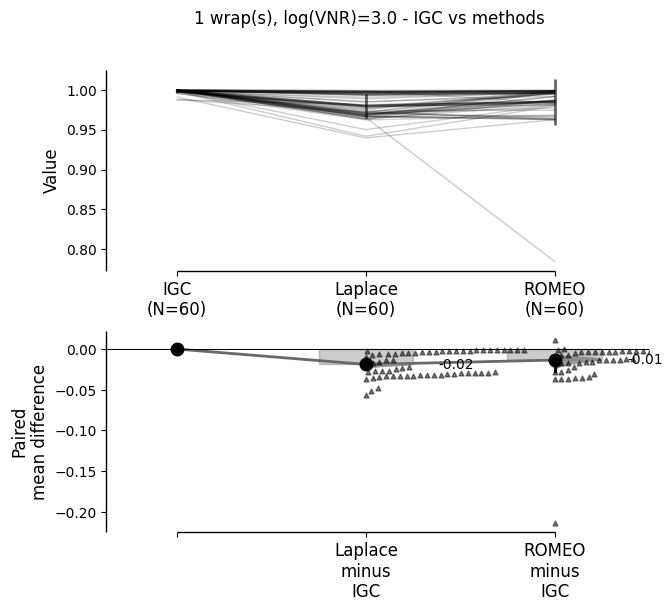

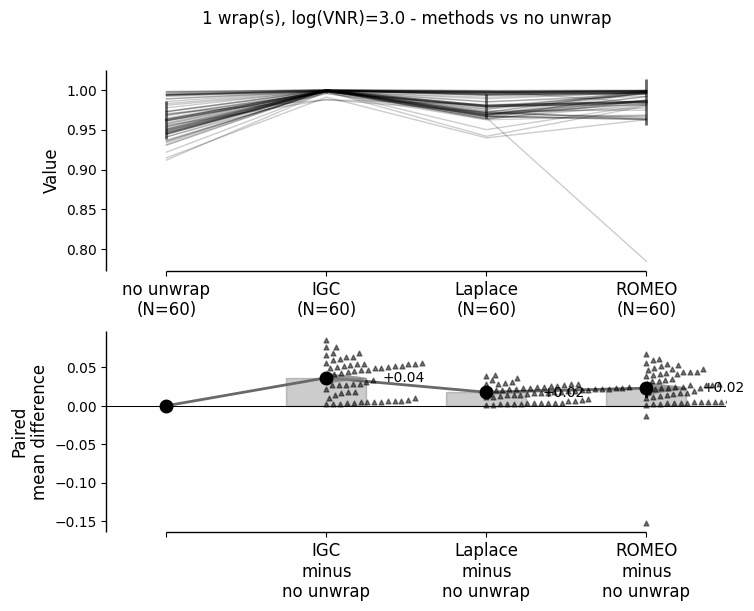

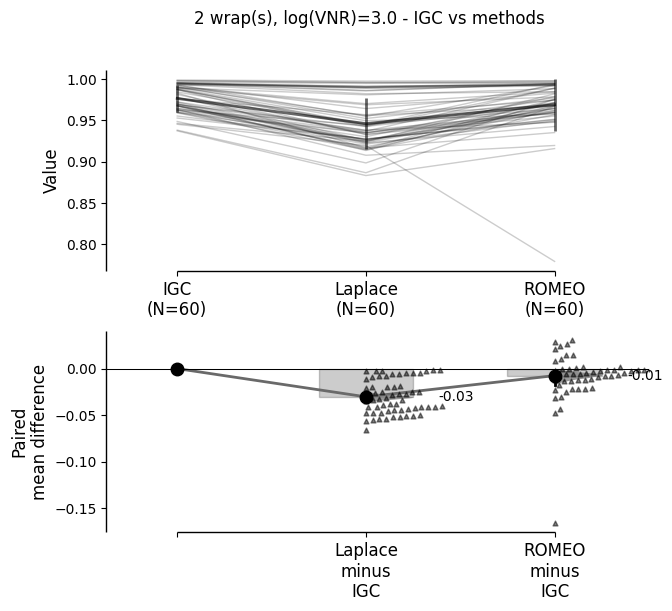

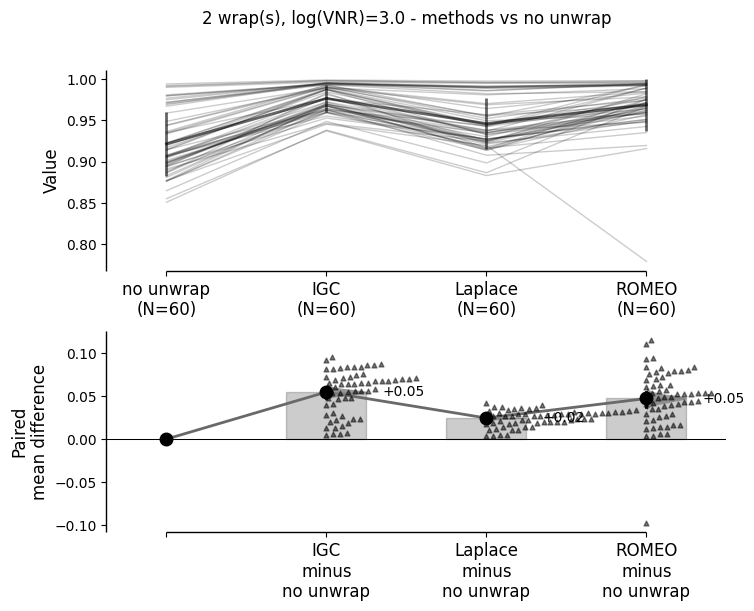

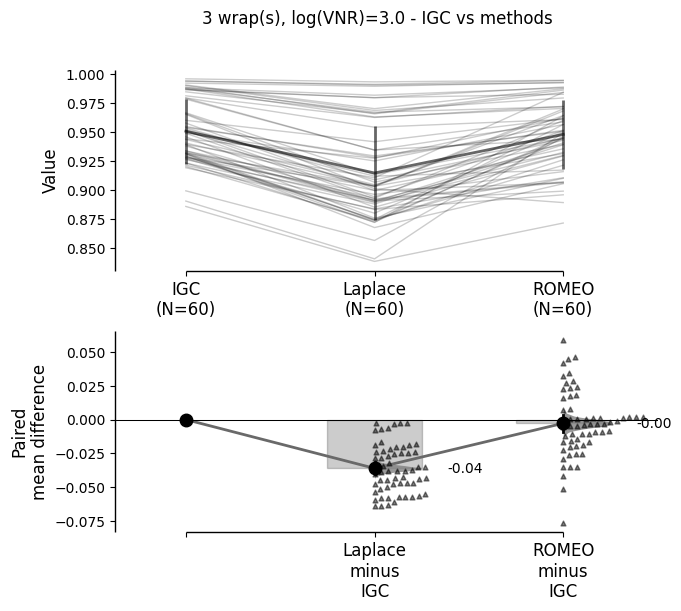

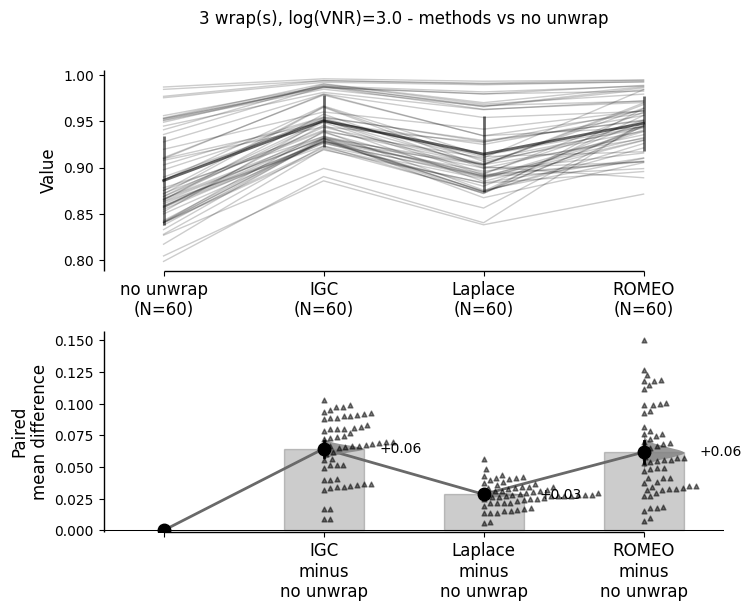

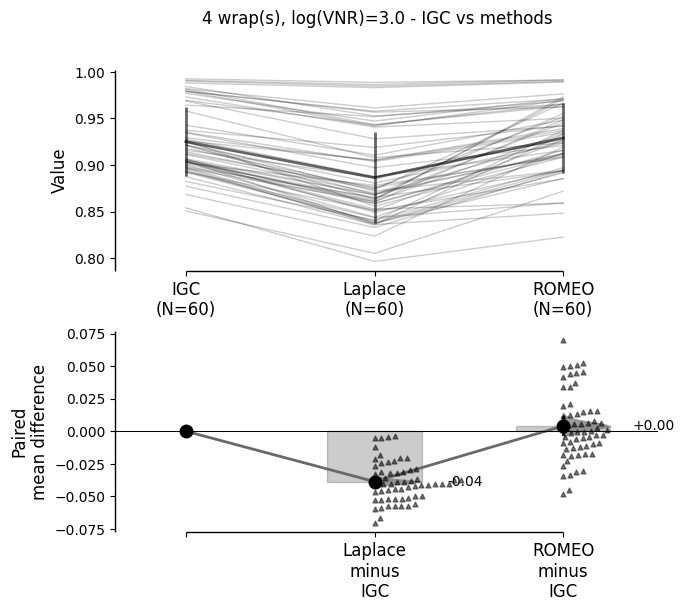

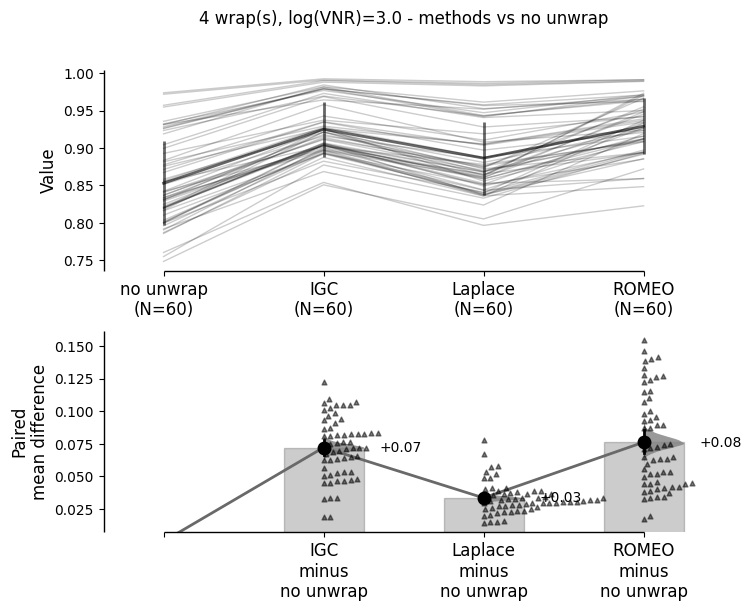

In [8]:
CUMMING_VNR = max(vnr_levels)
CUMMING_WRAPS = (1, 2, 3, 4)

for wraps in CUMMING_WRAPS:
    wide = (cases[(cases.vnr == CUMMING_VNR) & (cases.num_wraps == wraps)]
            .pivot(index='subject', columns='algorithm', values='correct_fraction'))
    wide['no unwrap'] = baseline.xs(wraps, level='num_wraps')  # dabest reads labels as regex
    wide = wide.reset_index()

    fig = dabest.load(wide, idx=tuple(algorithms), paired='baseline',
                      id_col='subject').mean_diff.plot(fig_size=(7, 6), raw_marker_size=3)
    fig.suptitle(f'{wraps} wrap(s), log(VNR)={CUMMING_VNR} - IGC vs methods')

    fig = dabest.load(wide, idx=('no unwrap', *algorithms), paired='baseline',
                      id_col='subject').mean_diff.plot(fig_size=(8, 6), raw_marker_size=3)
    fig.suptitle(f'{wraps} wrap(s), log(VNR)={CUMMING_VNR} - methods vs no unwrap')

### Forest plot (DABEST) - every cell at a glance

One contrast per (algorithm, wrap count), each paired against that subject's own wrapped input.
The dot is the mean paired difference, the bar its BCa 95% CI, and the violin the **bootstrap
distribution of the mean** - i.e. how well the mean is pinned down, not how much the subjects
differ from each other. For the spread across subjects see the next figure.

Effect sizes here are on the raw `correct_fraction` scale (what DABEST differences directly),
not the normalised `improvement` of the heatmaps.

c:\Users\jar048\.conda\envs\evalgc\Lib\site-packages\dabest\_effsize_objects.py:523: UserWarning: The lower limit of the BCa interval of baseline curve cannot be computed. It is set to the effect size itself. All bootstrap values were likely all the same.
  warnings.warn(err_temp.substitute(lim_type="lower"), stacklevel=0)
c:\Users\jar048\.conda\envs\evalgc\Lib\site-packages\dabest\_effsize_objects.py:527: UserWarning: The upper limit of the BCa interval of baseline curve cannot be computed. It is set to the effect size itself. All bootstrap values were likely all the same.
  warnings.warn(err_temp.substitute(lim_type="upper"), stacklevel=0)
c:\Users\jar048\.conda\envs\evalgc\Lib\site-packages\dabest\_effsize_objects.py:523: UserWarning: The lower limit of the BCa interval of baseline curve cannot be computed. It is set to the effect size itself. All bootstrap values were likely all the same.
  warnings.warn(err_temp.substitute(lim_type="lower"), stacklevel=0)
c:\Users\jar048\.conda\en

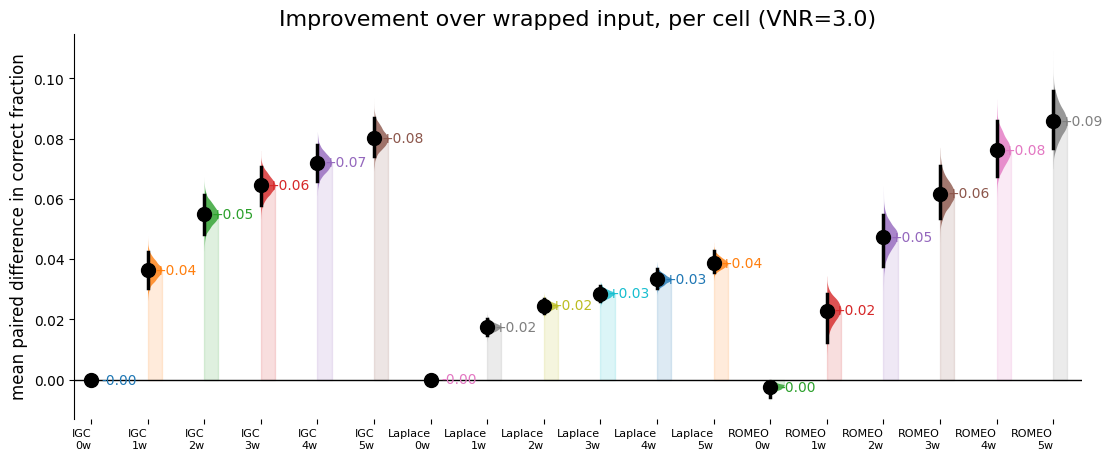

In [9]:
FOREST_VNR = max(vnr_levels)

contrasts, labels = [], []
for algo in algorithms:
    for wraps in wraps_levels:
        wide = (cases[(cases.vnr == FOREST_VNR) & (cases.num_wraps == wraps)
                      & (cases.algorithm == algo)][['subject', 'correct_fraction']]
                .rename(columns={'correct_fraction': algo}))
        wide['no unwrap'] = baseline.xs(wraps, level='num_wraps').reindex(wide.subject).values
        contrasts.append(dabest.load(wide, idx=('no unwrap', algo), paired='baseline',
                                     id_col='subject'))
        labels.append(f'{algo}\n{wraps}w')

# ~15 bootstrap runs -> takes a few seconds
fig = dabest.forest_plot(contrasts, labels=labels, fig_size=(13, 5), labels_fontsize=8,
                         labels_rotation=0, ylabel='mean paired difference in correct fraction',
                         title=f'Improvement over wrapped input, per cell (VNR={FOREST_VNR})')

### Spread across subjects

What the heatmap means hide: how consistent each cell is. Violin + one dot per subject, on the
same normalised `improvement` scale as the heatmaps, with the black diamond marking the mean.

The y-axis is clipped - ROMEO produces heavy negative outliers (down to about -20, i.e. it turns
a mostly-correct volume into a mostly-wrong one) that would otherwise flatten every other
violin. Cells with clipped points are annotated with the count.

num_wraps,0,1,2,3,4,5
fraction of subjects made worse,,,,,,
IGC,0.466667,0.000000,0.000000,0.0,0.0,0.0
Laplace,0.466667,0.000000,0.000000,0.0,0.0,0.0
ROMEO,1.000000,0.033333,0.016667,0.0,0.0,0.0


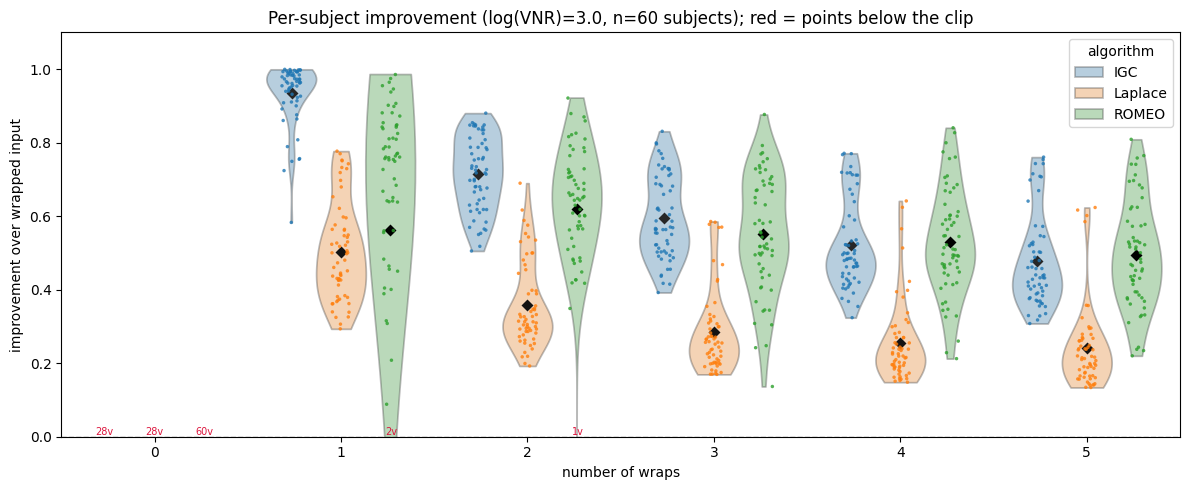

In [ ]:
SPREAD_VNR = max(vnr_levels)
YLIM = (0.0, 1.1)

spread = cases[cases.vnr == SPREAD_VNR]

fig, axis = plt.subplots(figsize=(12, 5))
sn.violinplot(data=spread, x='num_wraps', y='improvement', hue='algorithm', cut=0,
              density_norm='width', inner=None, alpha=0.35, ax=axis)
sn.stripplot(data=spread, x='num_wraps', y='improvement', hue='algorithm', dodge=True,
             size=2.5, jitter=0.15, linewidth=0, alpha=0.8, ax=axis, legend=False)
sn.pointplot(data=spread, x='num_wraps', y='improvement', hue='algorithm', dodge=0.53,
             linestyle='none', markers='D', markersize=4, errorbar=None,
             palette='dark:black', ax=axis, legend=False)

# flag what the clip hides
for x, wraps in enumerate(wraps_levels):
    for offset, algo in zip(np.linspace(-0.27, 0.27, len(algorithms)), algorithms):
        cell = spread[(spread.num_wraps == wraps) & (spread.algorithm == algo)].improvement
        n_below = int((cell < YLIM[0]).sum())
        if n_below:
            axis.annotate(f'{n_below}v', (x + offset, YLIM[0]), ha='center', va='bottom',
                          fontsize=7, color='crimson')

# axis.axhline(0, color='grey', ls='--', lw=1)
axis.set(xlabel='number of wraps', ylabel='improvement over wrapped input', ylim=YLIM,
         title=f'Per-subject improvement (log(VNR)={SPREAD_VNR}, '
               f'n={spread.subject.nunique()} subjects); red = points below the clip')
fig.tight_layout()

# how often does each method actually hurt?
(spread.assign(worse=spread.improvement < 0)
 .groupby(['algorithm', 'num_wraps']).worse.mean()
 .unstack().rename_axis('fraction of subjects made worse'))

### Whorlmap (DABEST)

The heatmap version of the estimation plot: same grid as the improvement heatmap, but each cell
is a **spiral** instead of a flat colour. DABEST sorts that cell's bootstrap distribution and
lays the quantile ladder out from the cell's outer edge inwards, so:

* **flat, uniform cell** -> tight bootstrap distribution, the effect is pinned down
* **strong edge-to-centre gradient** -> wide distribution, the effect is uncertain
* overall cell colour -> the mean effect, as in the ordinary heatmap

`reverse_neg=True` flips predominantly negative contrasts so the largest magnitude always sits
at the same end of the spiral, which keeps ROMEO's cells comparable with the others.

Like the forest plot, this shows the bootstrap distribution **of the mean difference** - it is a
picture of estimation uncertainty, not of how much individual subjects differ. The violin figure
above remains the one to read for across-subject spread.

c:\Users\jar048\.conda\envs\evalgc\Lib\site-packages\dabest\_effsize_objects.py:523: UserWarning: The lower limit of the BCa interval of baseline curve cannot be computed. It is set to the effect size itself. All bootstrap values were likely all the same.
  warnings.warn(err_temp.substitute(lim_type="lower"), stacklevel=0)
c:\Users\jar048\.conda\envs\evalgc\Lib\site-packages\dabest\_effsize_objects.py:527: UserWarning: The upper limit of the BCa interval of baseline curve cannot be computed. It is set to the effect size itself. All bootstrap values were likely all the same.
  warnings.warn(err_temp.substitute(lim_type="upper"), stacklevel=0)
c:\Users\jar048\.conda\envs\evalgc\Lib\site-packages\dabest\_effsize_objects.py:523: UserWarning: The lower limit of the BCa interval of baseline curve cannot be computed. It is set to the effect size itself. All bootstrap values were likely all the same.
  warnings.warn(err_temp.substitute(lim_type="lower"), stacklevel=0)
c:\Users\jar048\.conda\en

,0 wraps,1 wraps,2 wraps,3 wraps,4 wraps,5 wraps
IGC,-0.0000,0.0364,0.0550,0.0646,0.0721,0.0802
Laplace,-0.0000,0.0175,0.0246,0.0285,0.0334,0.0388
ROMEO,-0.0025,0.0229,0.0474,0.0618,0.0762,0.0858


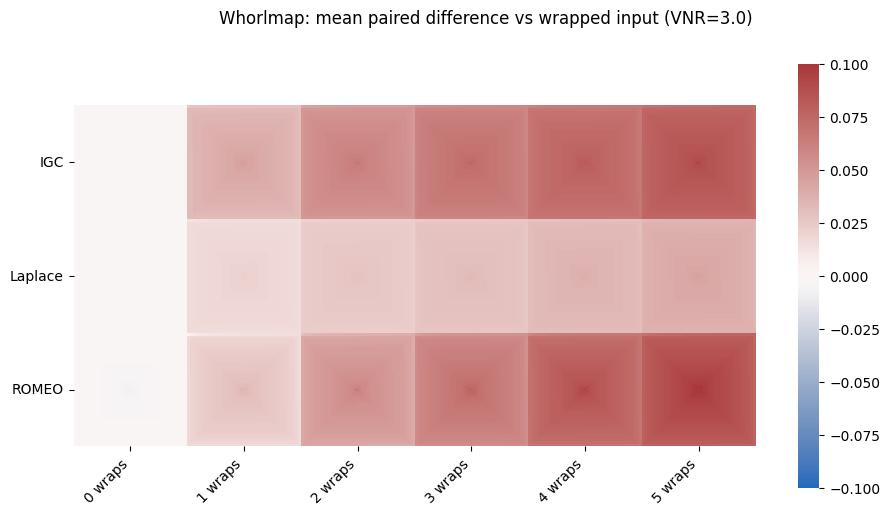

In [11]:
from dabest.multi import combine, whorlmap

WHORL_VNR = max(vnr_levels)

def _contrast(algo, wraps, vnr):
    """One paired contrast: algorithm vs that subject's own wrapped input."""
    wide = (cases[(cases.vnr == vnr) & (cases.num_wraps == wraps) & (cases.algorithm == algo)]
            [['subject', 'correct_fraction']].rename(columns={'correct_fraction': algo}))
    wide['no unwrap'] = baseline.xs(wraps, level='num_wraps').reindex(wide.subject).values
    return dabest.load(wide, idx=('no unwrap', algo), paired='baseline', id_col='subject')

# rows = algorithm, columns = wrap count. Swap to rows=wraps / cols=vnr_levels for a per-algorithm
# whorlmap matching the improvement heatmap - that is 45 contrasts each, so roughly 1 min per map.
contrast_grid = [[_contrast(algo, wraps, WHORL_VNR) for wraps in wraps_levels]
                 for algo in algorithms]

# bootstrapping ~15 contrasts takes ~20 s
multi = combine(contrast_grid,
                labels=[f'{w} wraps' for w in wraps_levels],
                row_labels=list(algorithms))

fig, axis, mean_delta = whorlmap(
    multi, n=41, fig_size=(11, 5.5), cmap='vlag', vmin=-0.10, vmax=0.10,
    heatmap_kwargs={'linewidths': 0},   # n x n sub-pixels per cell: any linewidth draws a mesh
    title=f'Whorlmap: mean paired difference vs wrapped input (VNR={WHORL_VNR})')

mean_delta.round(4)

# Clin dataset
Segment??
Show slice with max wrap and print a before and after image

### Heatmap

In [12]:
clin_path = data_path / "clin_4d_data"
gt_path = clin_path / "clin_4d_data_gt"

subjects = sorted({f.split("_a350")[0] for f in os.listdir(clin_path) if f.endswith(".npy")})
wraps = [1, 2]

clin_heatmaps = {}
for algorithm, out_path in out_paths.items():
    heatmap_df = pd.DataFrame(np.nan, index=wraps, columns=subjects)
    heatmap_df.index.name = "wraps"
    heatmap_df.columns.name = "subject"

    for subject in subjects:
        truth_array = np.angle(io.load_numpy_data(gt_path / f"{subject}_a350.npy"))
        mask = np.abs(truth_array) != 0
        for wrapcount in wraps:
            div_factor = 1 + 2 * wrapcount
            unwrapped_path = out_path / f"{subject}_a350_{wrapcount}wraps_unwrapped.npy"
            if not unwrapped_path.is_file():
                continue
            out_array = io.load_numpy_data(unwrapped_path)
            diff = np.abs(truth_array * div_factor - out_array) < np.pi
            heatmap_df.at[wrapcount, subject] = diff[mask].mean()
    heatmap_df["mean"] = heatmap_df[subjects].mean(axis=1)
    clin_heatmaps[algorithm] = heatmap_df


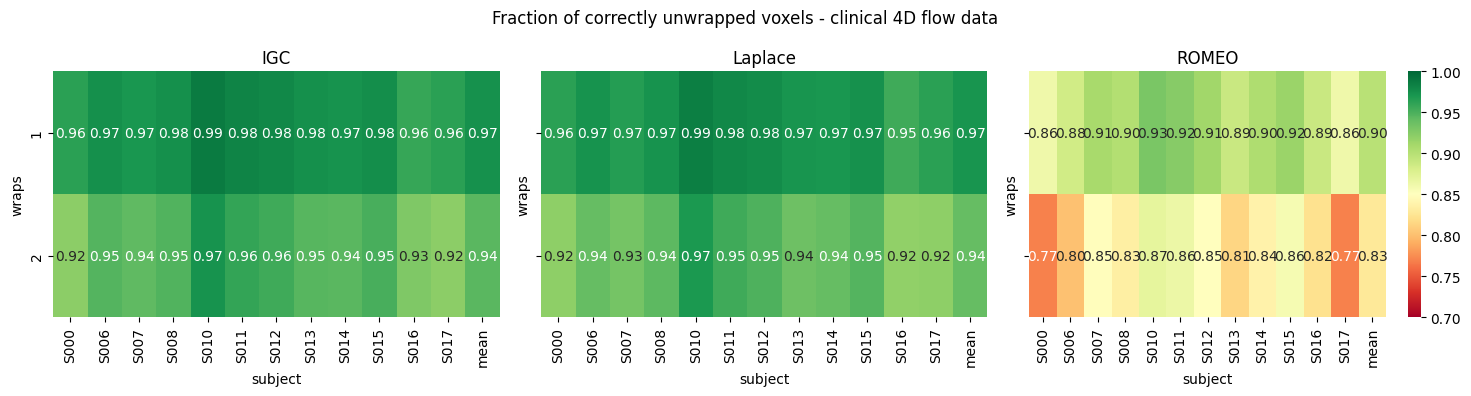

In [13]:
fig, axes = plt.subplots(1, len(clin_heatmaps), figsize=(5 * len(clin_heatmaps), 4), sharey=True)

for axis, (algorithm, heatmap_df) in zip(axes, clin_heatmaps.items()):
    sn.heatmap(heatmap_df, annot=True, fmt=".2f", vmin=0.7, vmax=1.0,
               cmap="RdYlGn", cbar=axis is axes[-1], ax=axis)
    axis.set_title(algorithm)

fig.suptitle("Fraction of correctly unwrapped voxels - clinical 4D flow data")
fig.tight_layout()
